In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# Chemin racine du dataset
DATA_ROOT = "/kaggle/input/datasets/pshikk/node-21-dataset-untampered"

# Afficher l'arborescence (2 niveaux)
for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level <= 1:
        for f in files[:5]:
            print(f"{'  '*(level+1)}{f}")
        if len(files) > 5:
            print(f"{'  '*(level+1)}... ({len(files)} fichiers total)")

node-21-dataset-untampered/
  ct_patches/
    segmentation/
    nodule_patches/
  cxr_images/
    original_data/
    proccessed_data/


In [2]:
# Explorer les sous-dossiers clés
for subdir in ["cxr_images/original_data", "cxr_images/proccessed_data", "ct_patches/nodule_patches", "ct_patches/segmentation"]:
    full_path = os.path.join(DATA_ROOT, subdir)
    if os.path.exists(full_path):
        items = os.listdir(full_path)
        print(f"\n📁 {subdir}/  ({len(items)} éléments)")
        for item in items[:10]:
            item_path = os.path.join(full_path, item)
            if os.path.isdir(item_path):
                n = len(os.listdir(item_path))
                print(f"   📂 {item}/  ({n} fichiers)")
            else:
                print(f"   📄 {item}")
        if len(items) > 10:
            print(f"   ... ({len(items)} total)")


📁 cxr_images/original_data/  (3 éléments)
   📂 images/  (4882 fichiers)
   📄 metadata.csv
   📄 filenames_orig_and_new.csv

📁 cxr_images/proccessed_data/  (3 éléments)
   📄 simulated_metadata.csv
   📂 images/  (4882 fichiers)
   📄 metadata.csv

📁 ct_patches/nodule_patches/  (1186 éléments)
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.213854687290736562463866711534_dcm_0.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.286217539434358186648717203667_dcm_2.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.241083615484551649610616348856_dcm_0.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.122914038048856168343065566972_dcm_2.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.964952370561266624992539111877_dcm_2.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.320111824803959660037459294083_dcm_0.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.170052181746004939527661217512_dcm_1.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.259124675432205040899951626253_dcm_0.mha
   📄 1.3.6.1.4.1.14519.5.2.1.6279.6001.225227615446398900698431118292

In [3]:
# Lire les métadonnées
meta_orig = pd.read_csv(os.path.join(DATA_ROOT, "cxr_images/original_data/metadata.csv"))
meta_proc = pd.read_csv(os.path.join(DATA_ROOT, "cxr_images/proccessed_data/metadata.csv"))
meta_sim  = pd.read_csv(os.path.join(DATA_ROOT, "cxr_images/proccessed_data/simulated_metadata.csv"))

print("=== metadata.csv (original) ===")
print(meta_orig.shape)
print(meta_orig.dtypes)
print(meta_orig.head(5))

print("\n=== metadata.csv (processed) ===")
print(meta_proc.shape)
print(meta_proc.head(3))

print("\n=== simulated_metadata.csv ===")
print(meta_sim.shape)
print(meta_sim.head(3))

=== metadata.csv (original) ===
(5224, 7)
Unnamed: 0     int64
height         int64
img_name      object
label          int64
width          int64
x              int64
y              int64
dtype: object
   Unnamed: 0  height   img_name  label  width    x    y
0           0      94  n0239.mha      1     92  776  538
1           1      40  n0342.mha      1     27  215  641
2           2     108  n0996.mha      1    155  695  342
3           3      75  n0418.mha      1     72  319  447
4           4      69  n0538.mha      1     62  599  590

=== metadata.csv (processed) ===
(5224, 7)
   Unnamed: 0  height   img_name  label  width    x    y
0           0      94  n0239.mha      1     92  776  579
1           1      40  n0342.mha      1     27  223  642
2           2     111  n0996.mha      1    159  687  310

=== simulated_metadata.csv ===
(7576, 6)
   Unnamed: 0  height   img_name  width    x    y
0           0      64  c0001.mha     64  625  380
1           1     164  c0013.mha    164  

In [4]:
# Images uniques et labels
img_labels = meta_orig.groupby('img_name')['label'].max().reset_index()
n_total = len(img_labels)
n_pos = (img_labels['label'] == 1).sum()
n_neg = (img_labels['label'] == 0).sum()

print(f"=== Images CXR uniques : {n_total} ===")
print(f"  Avec nodule    (label=1) : {n_pos}  ({100*n_pos/n_total:.1f}%)")
print(f"  Sans nodule    (label=0) : {n_neg}  ({100*n_neg/n_total:.1f}%)")

print(f"\n=== Annotations (bounding boxes) : {len(meta_orig)} lignes ===")
print(f"  Nodules annotés (label=1) : {(meta_orig['label']==1).sum()}")
print(f"  Taille des nodules (px) :")
print(f"    width  – min:{meta_orig['width'].min()}  max:{meta_orig['width'].max()}  mean:{meta_orig['width'].mean():.1f}")
print(f"    height – min:{meta_orig['height'].min()}  max:{meta_orig['height'].max()}  mean:{meta_orig['height'].mean():.1f}")

# Vérifier résolution d'une image
import SimpleITK as sitk
sample_img_path = os.path.join(DATA_ROOT, "cxr_images/original_data/images", img_labels['img_name'].iloc[0])
img = sitk.ReadImage(sample_img_path)
arr = sitk.GetArrayFromImage(img)
print(f"\n=== Résolution image (sample: {img_labels['img_name'].iloc[0]}) ===")
print(f"  Shape numpy : {arr.shape}  dtype: {arr.dtype}")
print(f"  Valeurs – min:{arr.min()}  max:{arr.max()}  mean:{arr.mean():.1f}")

=== Images CXR uniques : 4882 ===
  Avec nodule    (label=1) : 1134  (23.2%)
  Sans nodule    (label=0) : 3748  (76.8%)

=== Annotations (bounding boxes) : 5224 lignes ===
  Nodules annotés (label=1) : 1476
  Taille des nodules (px) :
    width  – min:0  max:400  mean:21.9
    height – min:0  max:415  mean:22.8

=== Résolution image (sample: c0001.mha) ===
  Shape numpy : (1024, 1024)  dtype: uint8
  Valeurs – min:0  max:244  mean:157.7


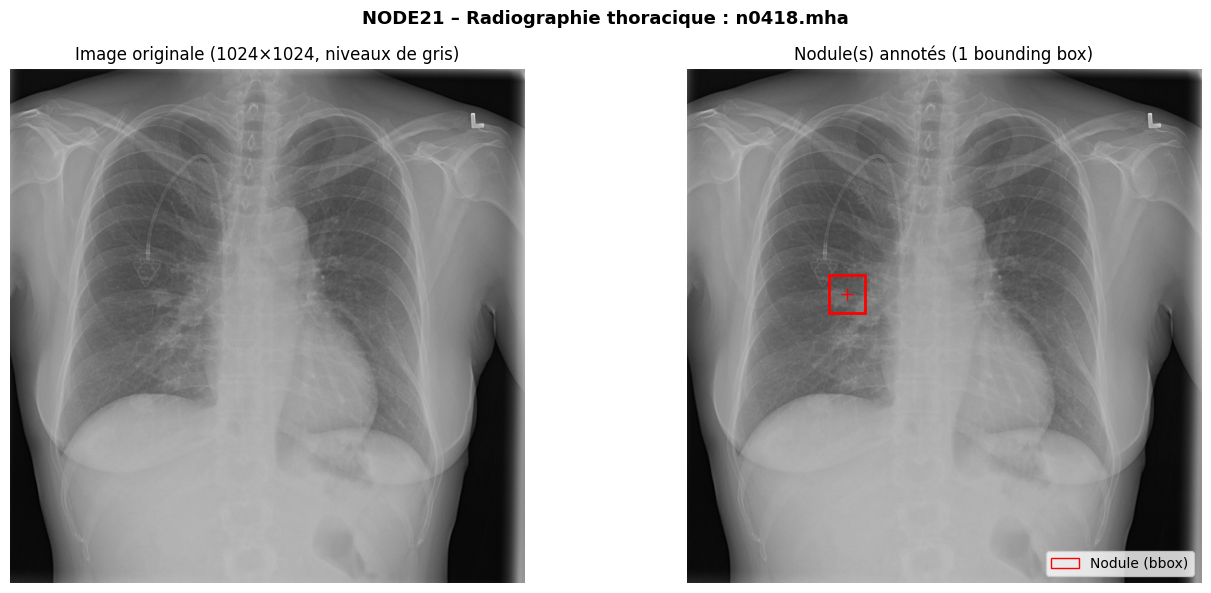

Nodule(s) dans cette image : taille moy. 72×75 px


In [5]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Choisir une image avec nodule(s)
img_with_nodule = meta_orig[meta_orig['label'] == 1]['img_name'].iloc[3]
nodules = meta_orig[meta_orig['img_name'] == img_with_nodule]

# Charger l'image
img_path = os.path.join(DATA_ROOT, "cxr_images/original_data/images", img_with_nodule)
arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"NODE21 – Radiographie thoracique : {img_with_nodule}", fontsize=13, fontweight='bold')

# --- Image brute ---
axes[0].imshow(arr, cmap='gray')
axes[0].set_title("Image originale (1024×1024, niveaux de gris)")
axes[0].axis('off')

# --- Image avec bounding boxes ---
axes[1].imshow(arr, cmap='gray')
for _, row in nodules.iterrows():
    x, y, w, h = row['x'], row['y'], row['width'], row['height']
    rect = patches.Rectangle((x - w//2, y - h//2), w, h,
                               linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].plot(x, y, 'r+', markersize=8)

axes[1].set_title(f"Nodule(s) annotés ({len(nodules)} bounding box{'es' if len(nodules)>1 else ''})")
axes[1].axis('off')

# Légende
from matplotlib.lines import Line2D
legend_elements = [patches.Patch(edgecolor='red', facecolor='none', label='Nodule (bbox)')]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig("node21_sample_cxr.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Nodule(s) dans cette image : taille moy. {nodules['width'].mean():.0f}×{nodules['height'].mean():.0f} px")

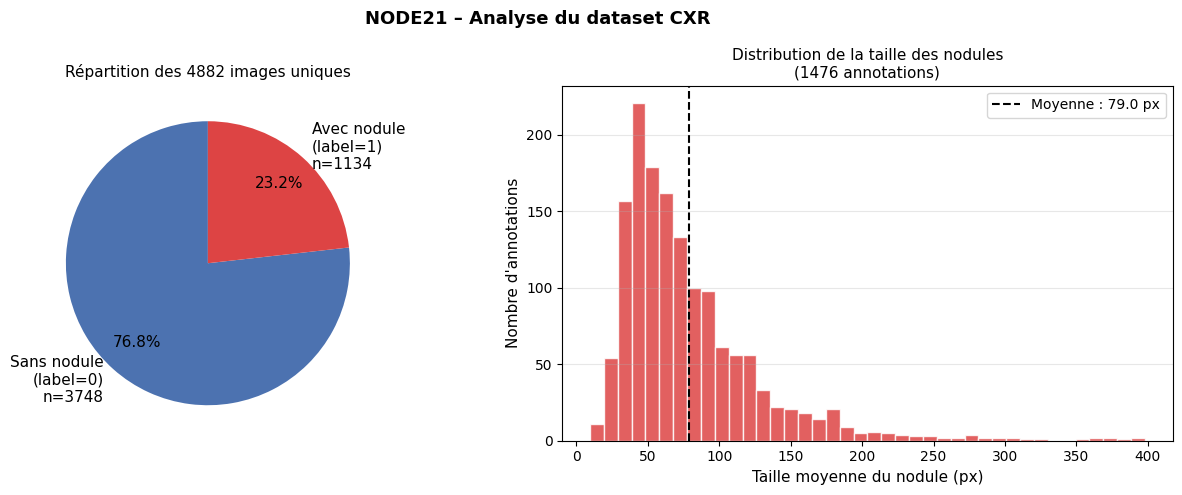

===== RÉSUMÉ POUR LA DIAPOSITIVE =====
Tâche            : classification binaire – nodule présent (1) / absent (0)
Format images    : 1024×1024 px, niveaux de gris (.mha), uint8
Total images     : 4882
  Avec nodule    : 1134 (23.2%)
  Sans nodule    : 3748 (76.8%)
Annotations bbox : 1476 nodules annotés
  Taille nodule  : 10 – 398 px  (moy. 79.0 px)
Nodules simulés  : 7576 annotations supplémentaires (simulated_metadata)
Split utilisé    : train / test déterministe (selon papier NODE21)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("NODE21 – Analyse du dataset CXR", fontsize=13, fontweight='bold')

# --- Camembert : répartition images ---
labels_pie = [f'Sans nodule\n(label=0)\nn={n_neg}', f'Avec nodule\n(label=1)\nn={n_pos}']
colors = ['#4C72B0', '#DD4444']
axes[0].pie([n_neg, n_pos], labels=labels_pie, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, pctdistance=0.75)
axes[0].set_title(f"Répartition des {n_total} images uniques", fontsize=11)

# --- Histogramme : taille des nodules ---
nodule_rows = meta_orig[meta_orig['label'] == 1].copy()
nodule_rows['taille_moy'] = (nodule_rows['width'] + nodule_rows['height']) / 2
nodule_rows = nodule_rows[nodule_rows['taille_moy'] > 0]  # exclure taille=0

axes[1].hist(nodule_rows['taille_moy'], bins=40, color='#DD4444', edgecolor='white', alpha=0.85)
axes[1].axvline(nodule_rows['taille_moy'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Moyenne : {nodule_rows['taille_moy'].mean():.1f} px")
axes[1].set_xlabel("Taille moyenne du nodule (px)", fontsize=11)
axes[1].set_ylabel("Nombre d'annotations", fontsize=11)
axes[1].set_title(f"Distribution de la taille des nodules\n({len(nodule_rows)} annotations)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("node21_stats.png", dpi=150, bbox_inches='tight')
plt.show()

# Résumé texte pour la diapo
print("===== RÉSUMÉ POUR LA DIAPOSITIVE =====")
print(f"Tâche            : classification binaire – nodule présent (1) / absent (0)")
print(f"Format images    : 1024×1024 px, niveaux de gris (.mha), uint8")
print(f"Total images     : {n_total}")
print(f"  Avec nodule    : {n_pos} ({100*n_pos/n_total:.1f}%)")
print(f"  Sans nodule    : {n_neg} ({100*n_neg/n_total:.1f}%)")
print(f"Annotations bbox : {len(nodule_rows)} nodules annotés")
print(f"  Taille nodule  : {nodule_rows['taille_moy'].min():.0f} – {nodule_rows['taille_moy'].max():.0f} px  (moy. {nodule_rows['taille_moy'].mean():.1f} px)")
print(f"Nodules simulés  : {len(meta_sim)} annotations supplémentaires (simulated_metadata)")
print(f"Split utilisé    : train / test déterministe (selon papier NODE21)")